# Proyek Predictive Analytics : Wine Quality Dataset
- **Nama:** Atifa Fiorenza
- **Email:** atifafiorenza24@gmail.com
- **ID Dicoding:** atifafiorenza24

## Import Library
We need to import some library that will be used in data preprocessing, data manipulation, and modeling.

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
import joblib

from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Download Dataset
Download the wine dataset. The dataset is from UCI Machine Learning and can be downloaded at Kaggle

https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

In [3]:
from google.colab import files
files.upload()  # Upload file kaggle.json dari lokal

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"atifa1110","key":"2972f282815cfd20a65bc10625d79e46"}'}

In [4]:
# Membuat folder .kaggle untuk credentials
!mkdir -p ~/.kaggle

# Menyalin file kaggle.json ke folder .kaggle
!cp kaggle.json ~/.kaggle/kaggle.json

# Memberikan permission agar kaggle.json dapat digunakan
!chmod 600 ~/.kaggle/kaggle.json

# Mendownload dataset Rice Leaf Diseases dari Kaggle
!kaggle datasets download -d yasserh/wine-quality-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0
  0% 0.00/21.5k [00:00<?, ?B/s]
100% 21.5k/21.5k [00:00<00:00, 97.9MB/s]


In [5]:
# Mengekstrak file dataset
!unzip wine-quality-dataset.zip -d wine

Archive:  wine-quality-dataset.zip
  inflating: wine/WineQT.csv         


## Load Dataset
Load and read wine dataset from folder wine

In [6]:
dataset = 'wine/WineQT.csv'

# Membaca CSV
df = pd.read_csv(dataset)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Data Understanding
First we want to find basic information from the dataset, like shape, data type, general stats, null values, and duplicate data. Than we will doing some EDA.

In [7]:
df.shape

(1143, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [10]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

## Data Visualization & EDA
uses univariate and multivariate visualizations to understand data distribution, detect outliers, and reveal relationships between features before modeling.

### Univariate Analysis
Univariate analysis is focusing on one variable at a time. The main goal is to describe, summarize, and find patterns in the data. At this stage, the data will be shown using a **histogram** to visualize the distribution and a **boxplot** to identify potential outliers and understand the spread of the data.

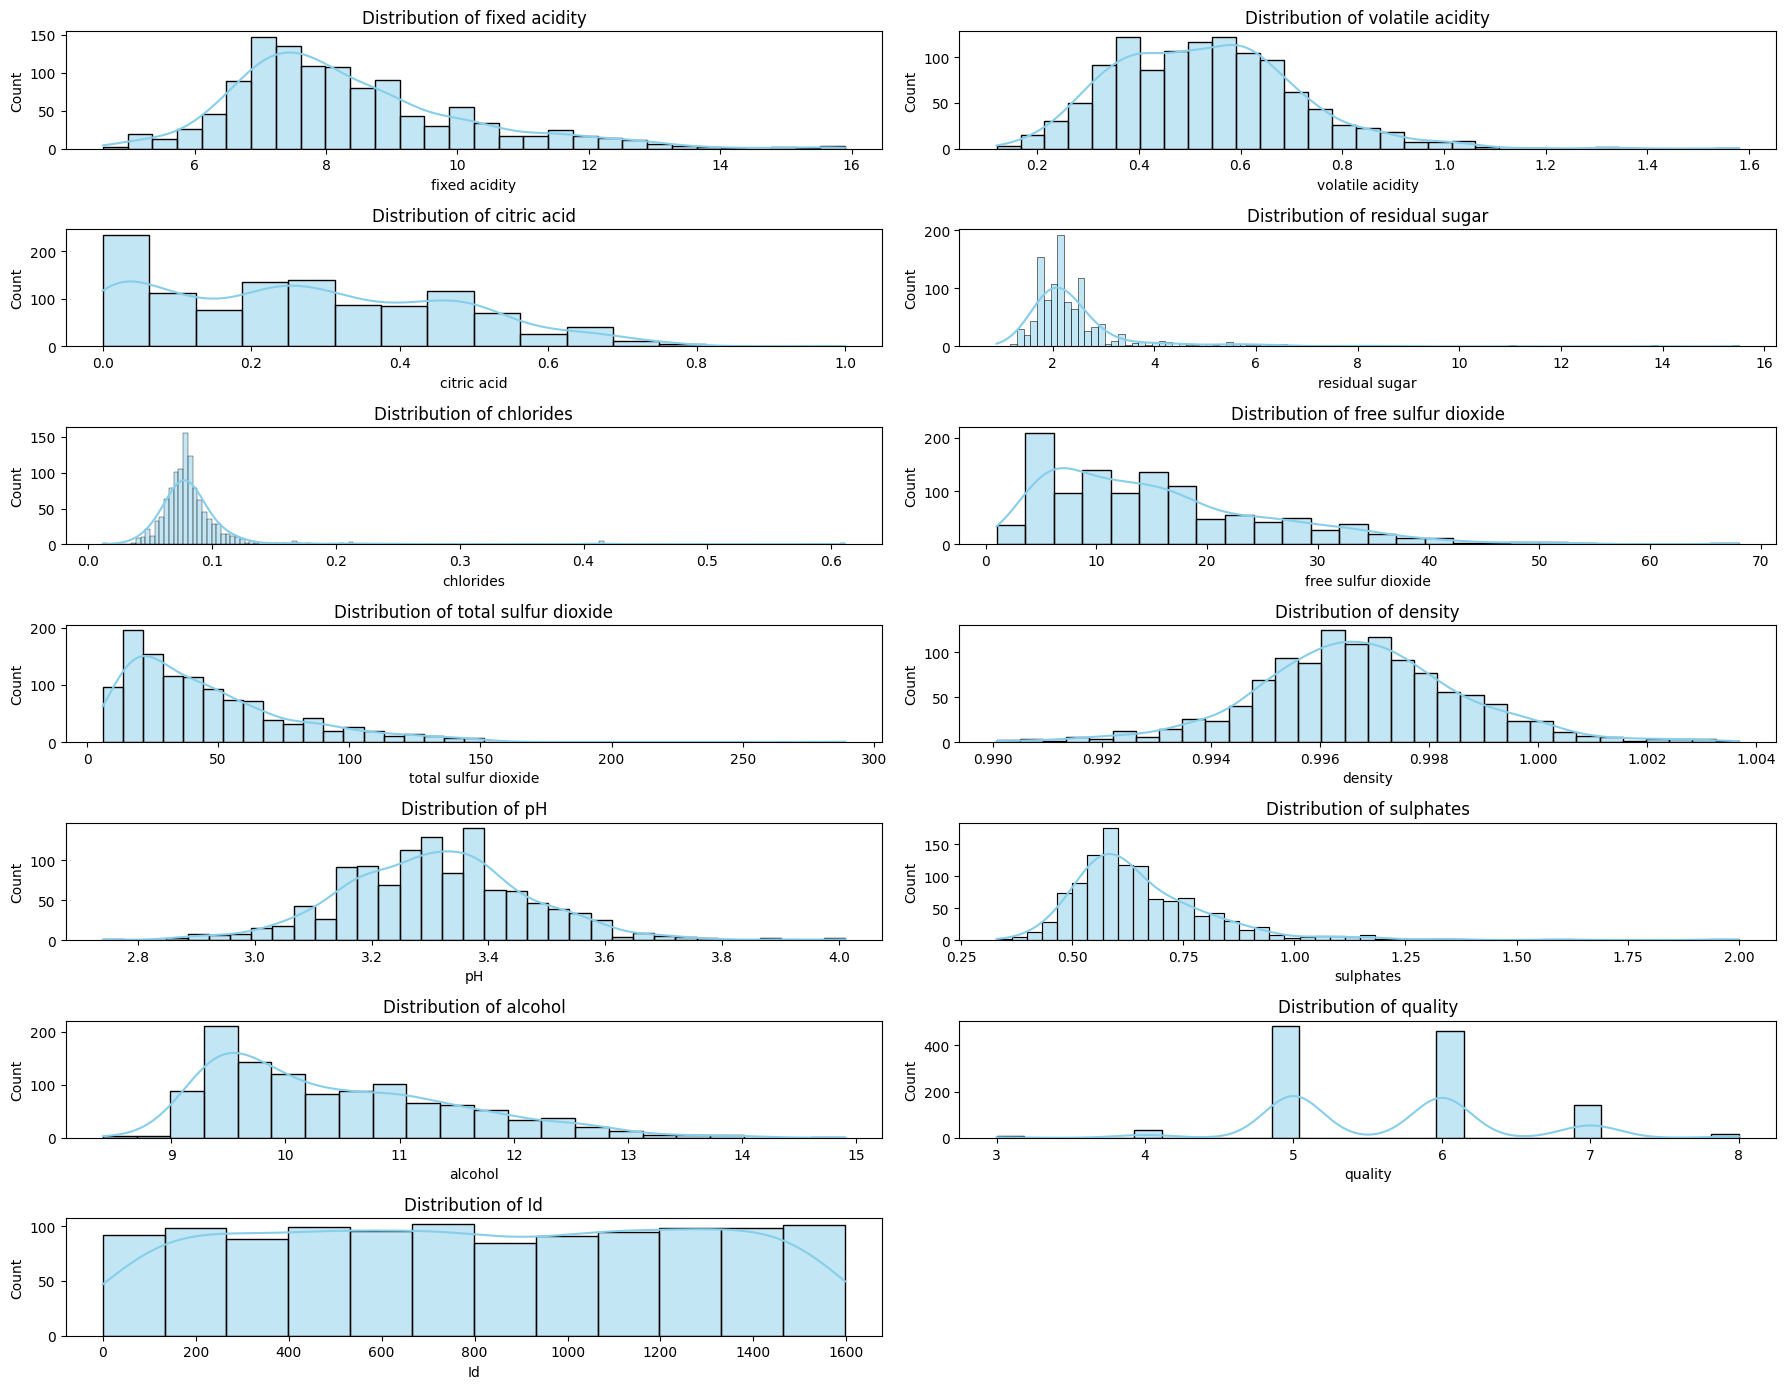

In [25]:
fig, axes = plt.subplots(7, 2, figsize=(18, 14))  # ukuran lebih besar
axes = axes.flatten()  # Supaya mudah di-loop

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hapus subplot yang tidak terpakai
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('univariate_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

Berdasarkan hasil histogram diatas :
- Banyak fitur miring ke kanan (skewed): Fitur seperti **residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, dan alcoho**l memiliki ekor panjang ke kanan. Ini menunjukkan **ada beberapa nilai yang sangat tinggi (outlier)**. Dalam plot KDE, kurvanya akan terlihat memanjang ke kanan.
- Beberapa fitur normal: Fitur volatile acidity, density, dan pH memiliki sebaran yang lebih simetris, mirip kurva lonceng. Plot KDE untuk fitur ini akan menyerupai bentuk lonceng.
- Fitur kategorikal: Fitur quality memiliki nilai yang terpusat di 5, 6, dan 7. Untuk fitur seperti ini, histogram lebih cocok daripada KDE.
- Identitas unik: Fitur Id bukan data yang berguna untuk analisis karena setiap nilainya unik.

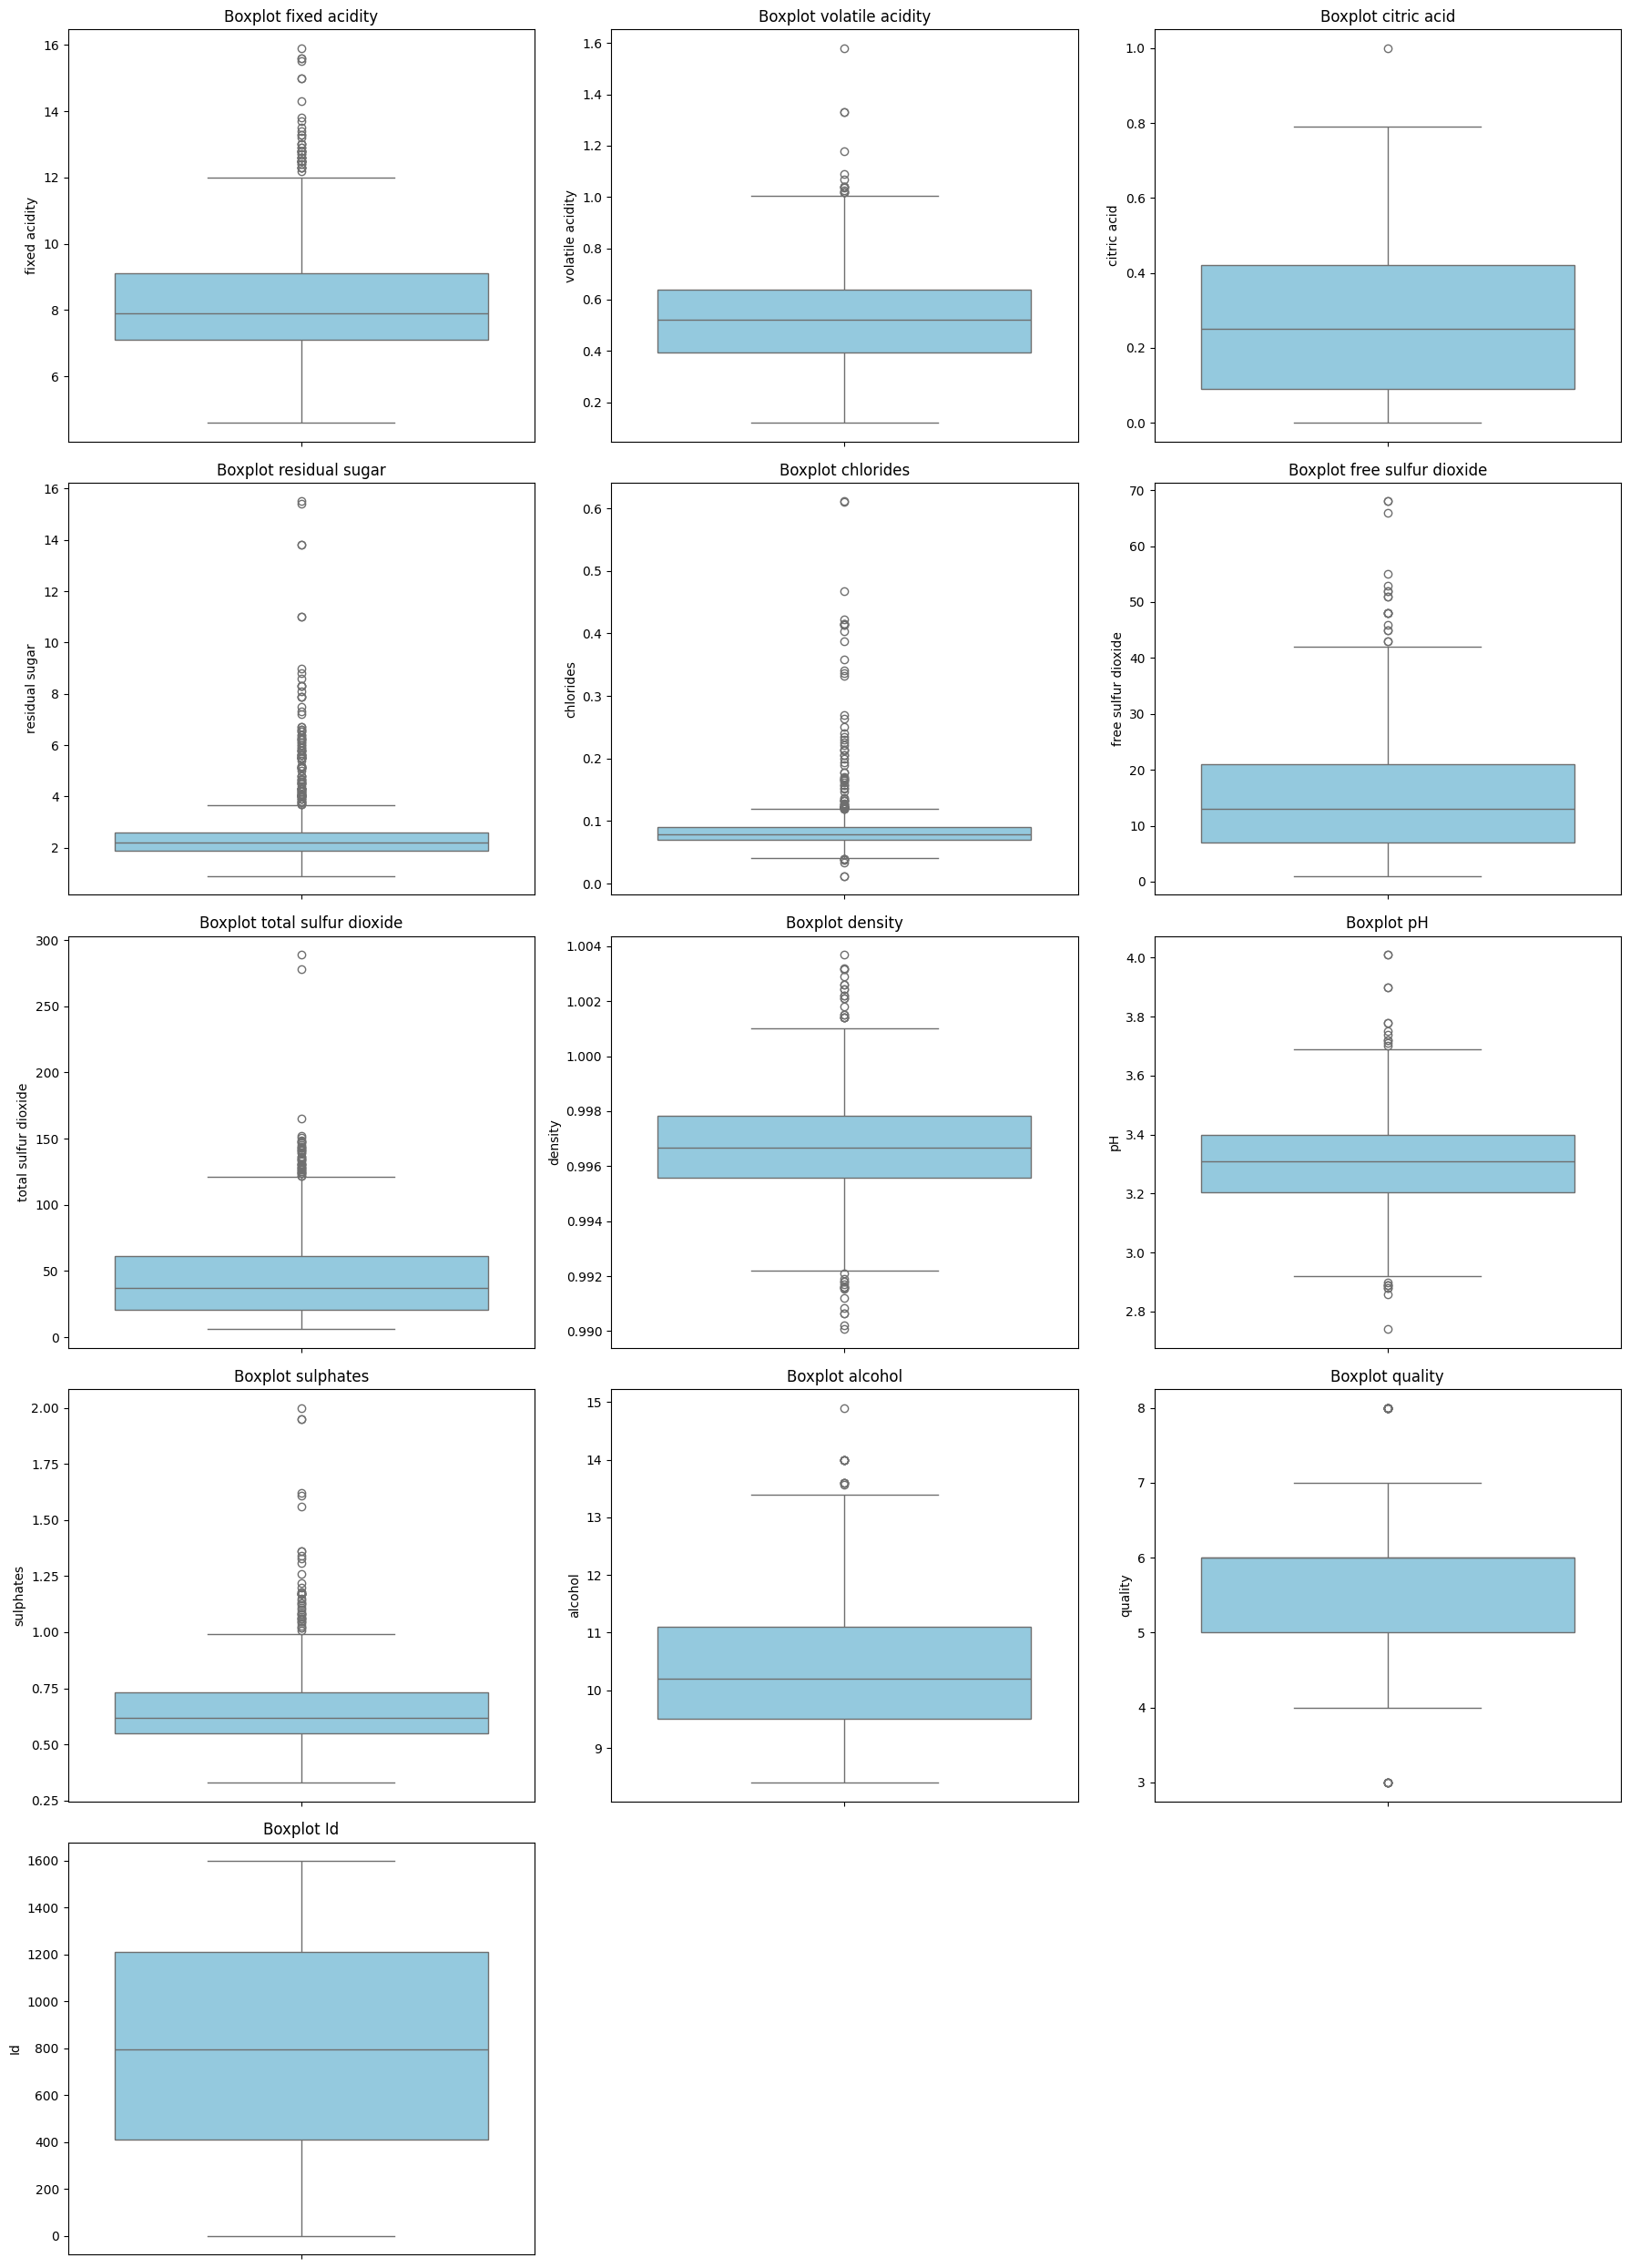

In [26]:
# Tentukan layout grid otomatis
n_cols = 3  # jumlah plot per baris
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()  # flatten supaya mudah di-loop

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

# Hapus subplot kosong jika ada
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('univariate_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Dari hasil boxplot, seluruh fitur memiliki outlier yang terlihat dari titik-titik di luar whisker. Beberapa fitur seperti **residual sugar, chlorides, free sulfur dioxide, dan total sulfur dioxide** memiliki jumlah outlier yang banyak, sedangkan fitur seperti **alcohol, sulphates, fixed acidity, volatile acidity, density, serta citric acid, pH, dan quality** memiliki outlier lebih sedikit. Hal ini perlu dipertimbangkan saat preprocessing untuk mengurangi dampak negatif outlier terhadap model.

### Multivariate Analysis
Multivariate analysis examines the relationships between three or more variables simultaneously. At this stage, the data will be shown using a **heatmap** to visualize the correlation matrix and a **scatterplot** to show the distribution of multiple features with respect to the target variable quality.

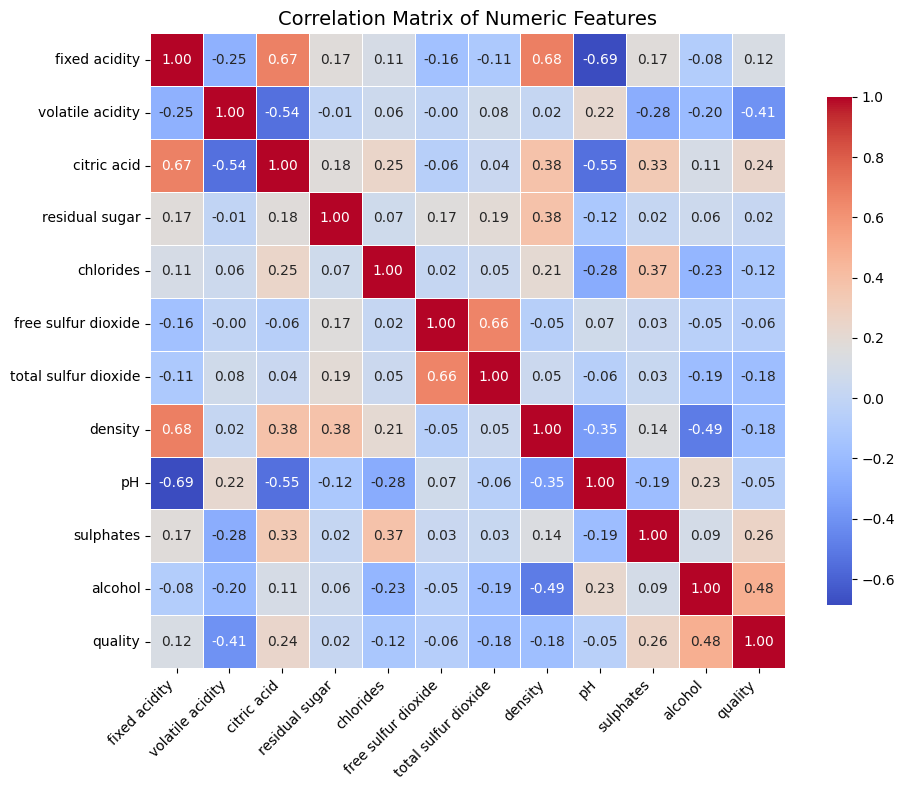

In [28]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('multivariate_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Dari hasil heatmap diatas ditemukan ada beberapa fitur yang memiliki korelasi yang cukup tinggi > 0.60 :
1. fixed acidity ↔ citric acid → **0.67**
2. fixed acidity ↔ density → **0.68**
3. free sulfur dioxide ↔ total sulfur dioxide → **0.66**

Cek korelasi ke target (quality) dan lihat fitur mana di setiap pasangan yang punya korelasi absolut lebih besar dengan target → itu yang dipertahankan.

1. fixed acidity → 0.12
2. citric acid → 0.24 ✅ (lebih kuat ke target)
density → -0.18
4. free sulfur dioxide → -0.06
5. total sulfur dioxide → -0.18 ✅ (lebih kuat ke target, walau negatif)

**Rekomendasi awal (berdasarkan korelasi ke target saja)**

**fixed acidity ↔ citric acid** →
- Dari segi ilmu oenologi (ilmu wine), citric acid
sering lebih berpengaruh ke kualitas persepsi rasa karena memberi freshness dan aroma citrus yang positif.
- Fixed acidity memang penting, tapi terlalu tinggi bisa membuat wine terlalu asam dan tidak enak.
- Korelasi ke quality (data kamu sebelum winsor): citric acid (0.24) > fixed acidity (0.12).
- **Rekomendasi: Pilih citric acid.**


**fixed acidity ↔ density** →
- Density banyak dipengaruhi gula & alkohol.
- Dalam penilaian kualitas, alkohol dan gula berperan besar pada body dan balance, jadi density bisa jadi indikator yang baik.
- Korelasi ke quality: density (-0.18) sedikit lebih besar absolutnya daripada fixed acidity (0.12), tapi negatif → artinya density tinggi sering muncul di wine yang kualitasnya lebih rendah (misalnya wine manis dengan gula sisa tinggi).
- **Rekomendasi: Pilih density**

**free sulfur dioxide ↔ total sulfur dioxide** →
- SO₂ memengaruhi stabilitas dan umur simpan, tapi kadar yang terlalu tinggi bisa merusak aroma & rasa.
- Free SO₂ lebih berpengaruh langsung terhadap rasa dan aroma saat ini dibanding total SO₂.
- Korelasi ke quality: total SO₂ (-0.18) > free SO₂ (-0.06) secara absolut, tapi arah negatif menunjukkan kadar tinggi sering menurunkan kualitas.
- **Rekomendasi: Pilih total sulfur dioxide**


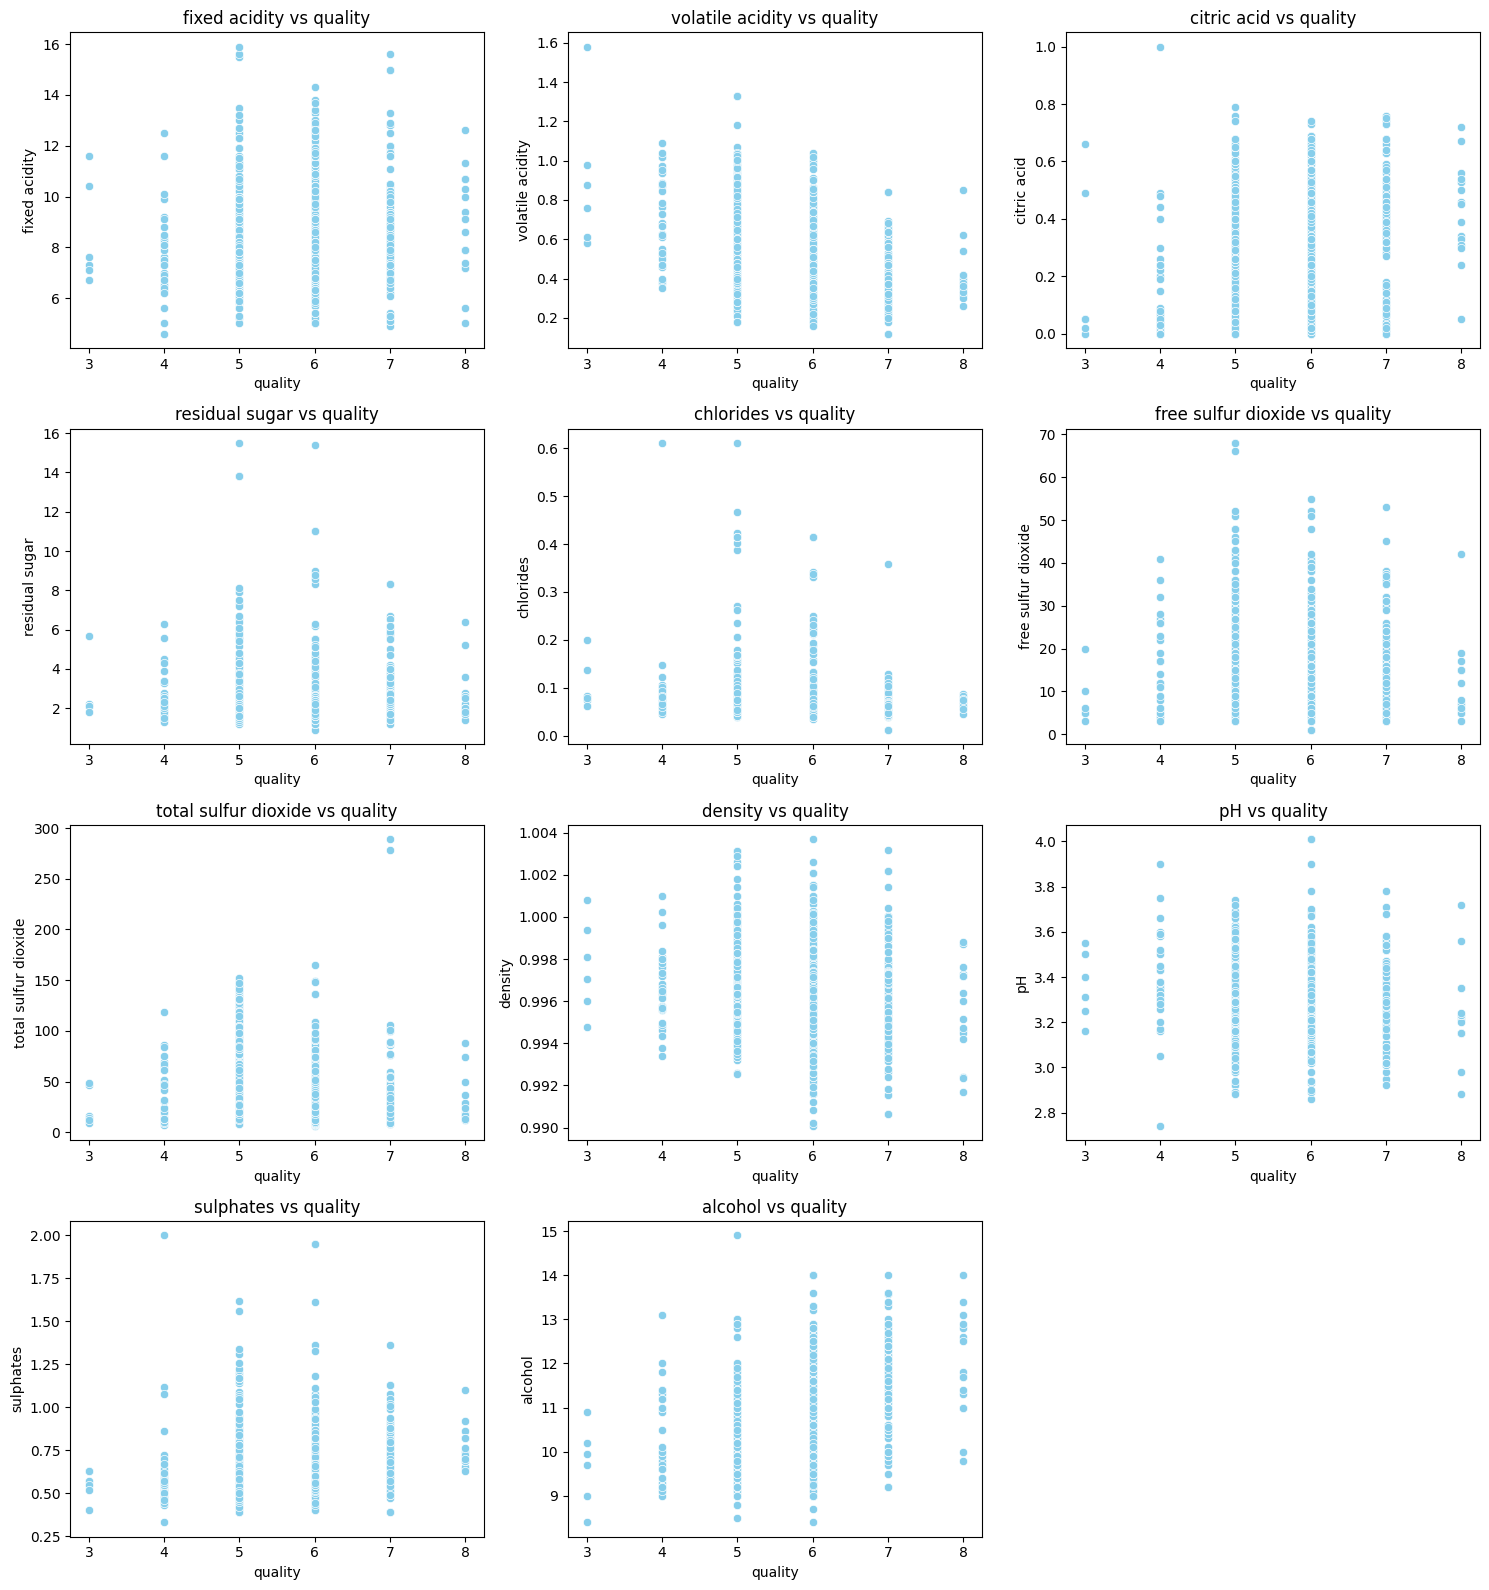

In [200]:
# Asumsi target = 'quality'
target = 'quality'

# Buat figure grid
num_cols = numeric_df.columns.drop(target)  # semua kolom numeric kecuali target
n_cols = 3  # jumlah kolom per row
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=numeric_df[target], y=numeric_df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} vs {target}')
    axes[i].set_xlabel(target)
    axes[i].set_ylabel(col)

# Hapus axes yang kosong kalau ada
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('multivariate_scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

Berdasarkan grafik scatter plot yang Anda berikan, berikut adalah pola yang terlihat dari hubungan antara setiap fitur dengan quality:

**Hubungan Positif (Semakin tinggi fitur, semakin tinggi quality)**
- **alcohol vs quality**:  Terlihat tren positif yang cukup jelas. Titik-titik data cenderung naik ke kanan, menunjukkan bahwa anggur dengan kadar alcohol yang lebih tinggi cenderung memiliki nilai quality yang lebih tinggi.

- **citric acid vs quality**:  Ada tren positif, meski tidak sekuat alcohol. Ketika kadar citric acid meningkat, quality juga cenderung meningkat, menunjukkan kontribusi positif terhadap rasa.

- **sulphates vs quality**:  Terlihat adanya tren positif. Peningkatan kadar sulphates seringkali berhubungan dengan nilai quality yang lebih tinggi.

**Hubungan Negatif (Semakin tinggi fitur, semakin rendah quality)**
- **volatile acidity vs quality**: Terdapat tren negatif yang cukup jelas. Semakin tinggi volatile acidity, semakin rendah nilai quality anggur. Ini menunjukkan bahwa keasaman yang mudah menguap tinggi tidak diinginkan untuk kualitas anggur yang baik.
- **density vs quality**:  Ada tren negatif, meskipun hubungannya tidak terlalu kuat. Peningkatan density cenderung berhubungan dengan sedikit penurunan quality.

**Hubungan Tidak Jelas (Korelasi lemah)**
- Untuk fitur-fitur seperti fixed acidity, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, dan pH, sebaran titik-titik datanya tampak acak dan tidak membentuk pola yang jelas. Ini menunjukkan bahwa korelasi antara fitur-fitur ini dengan quality sangat lemah atau hampir tidak ada.

## Dataset Preprocessing
After doing some analysis, we will do data preparation like removing null values, duplicates, and outliers. We also will normalize the feature to make them have equall weights for the ML models.

In [201]:
clean_df = df.copy()

In [202]:
# Menghitung jumlah nilai kosong di setiap kolom
missing_values = clean_df.isna().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [203]:
clean_df = clean_df.drop_duplicates()
clean_df.duplicated().sum()

np.int64(0)

After cleaning data, we will removing outlier from some of the important features. This is because outliers can make bias for the model. We use **winsorize** to reduce the influence of extreme values and optimize the model's performance.

In [204]:
# Fungsi untuk menghitung dan menampilkan data outlier
def ringkasan_outlier(df, kolom_list):
    summary = []

    for col in kolom_list:
        data = df[col]
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = data[(data < lower) | (data > upper)]
        jumlah = len(outliers)

        if jumlah == 0:
            keterangan = "Tidak ada outlier"
        else:
            # tandai ekstrem jika outlier jauh dari batas normal
            ekstrem = outliers[(outliers < lower*0.5) | (outliers > upper*1.5)]
            keterangan = "Ekstrem" if len(ekstrem) > 0 else "Wajar"

        summary.append({
            "Kolom": col,
            "Jumlah Outlier": jumlah,
            "Min Outlier": outliers.min() if jumlah > 0 else None,
            "Max Outlier": outliers.max() if jumlah > 0 else None,
            "Keterangan": keterangan
        })

    return pd.DataFrame(summary)

# Misal kolom numerik di dataset
numeric_df = clean_df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'])

tabel_outlier = ringkasan_outlier(clean_df, numeric_df)
print(tabel_outlier)

                   Kolom  Jumlah Outlier  Min Outlier  Max Outlier Keterangan
0          fixed acidity              44    12.200000     15.90000      Wajar
1       volatile acidity              14     1.020000      1.58000    Ekstrem
2            citric acid               1     1.000000      1.00000      Wajar
3         residual sugar             110     3.700000     15.50000    Ekstrem
4              chlorides              77     0.012000      0.61100    Ekstrem
5    free sulfur dioxide              18    43.000000     68.00000    Ekstrem
6   total sulfur dioxide              40   122.000000    289.00000    Ekstrem
7                density              36     0.990070      1.00369      Wajar
8                     pH              20     2.740000      4.01000      Wajar
9              sulphates              43     1.010000      2.00000    Ekstrem
10               alcohol              12    13.566667     14.90000      Wajar
11               quality              22     3.000000      8.000

As you can see, the outliers in the extreme category are volatile acidity, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, and sulphates. We need to treat these outliers using winsorization.

In [205]:
# Daftar kolom ekstrem
ekstrem_cols = ['volatile acidity', 'residual sugar', 'chlorides',
                'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

for col in ekstrem_cols:
    data = clean_df[col]

    # Hitung IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr

    # Proporsi outlier
    n = len(data)
    prop_upper = sum(data > upper_limit) / n
    prop_lower = sum(data < lower_limit) / n

    # Simpan kembali ke kolom aslinya
    clean_df[col] = winsorize(data, limits=(prop_lower, prop_upper))

In [206]:
clean_df.shape

(1143, 13)

Next, we also need to convert the target values from 10 categories into 3 categories, because we want to classify whether the wine is having a low , medium, or high qualty

In [207]:
clean_df['quality'].value_counts()

,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


In [208]:
clean_df["quality"] = pd.cut(clean_df["quality"], bins=[0, 4, 6, 10], labels=["low", "medium", "high"])

In [209]:
clean_df['quality'].value_counts()

,count
quality,
medium,945
high,159
low,39


In [210]:
# encode the target values, use 0 for bad, 1 for medium, and 2 for good
clean_df["quality"] = clean_df["quality"].map({"low": 0, "medium": 1,"high":2})

In [211]:
clean_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1,4


Drop Column Id because it can't use for modelling

In [212]:
# Drop kolom 'id' dari dataframe
clean_df = clean_df.drop('Id', axis=1)

In [213]:
# Cek hasilnya
clean_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1


The features are already cleaned, now we need to split for training and testing. Then we need transform it using robust scaler to make the data have equal weight, so it can increase the performance and reduce the bias of the ML models.

In [214]:
# Misal clean_df masih punya kolom 'quality'
X = clean_df.drop(['quality'], axis=1)
y = clean_df['quality']

In [215]:
print(X.columns)
print(y.value_counts())

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
quality
1    945
2    159
0     39
Name: count, dtype: int64


Split data into 80 train 20 test

In [216]:
# Split data into 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Apply SMOTE on the training set only to address class imbalance in the target variable

In [194]:
# SMOTE hanya di training set
smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X_train, y_train)
print("Distribusi asli:")
print(y.value_counts())
print("\nDistribusi setelah SMOTE:")
print(y_resample.value_counts())

Distribusi asli:
quality
1    945
2    159
0     39
Name: count, dtype: int64

Distribusi setelah SMOTE:
quality
0    756
1    756
2    756
Name: count, dtype: int64


Scale features using RobustScaler to reduce the impact of outliers

In [195]:
# Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_resample)
X_test_scaled = scaler.transform(X_test)

## Modelling
Because the data processing is already done, next we will train a model to do the classification. We will use 4 models, KNN, SVM, XGBoost and Random Forest. Those model are choosen because it some of the most common model used for classification.

In [196]:
# Model
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "SVM": SVC(C=1.0, kernel="rbf", gamma="scale"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

===== Random Forest =====
Score: 0.8472
              precision    recall  f1-score   support

         Low       0.11      0.12      0.12         8
      Medium       0.93      0.88      0.90       189
        High       0.64      0.84      0.73        32

    accuracy                           0.85       229
   macro avg       0.56      0.62      0.58       229
weighted avg       0.86      0.85      0.85       229

[[  1   7   0]
 [  8 166  15]
 [  0   5  27]]


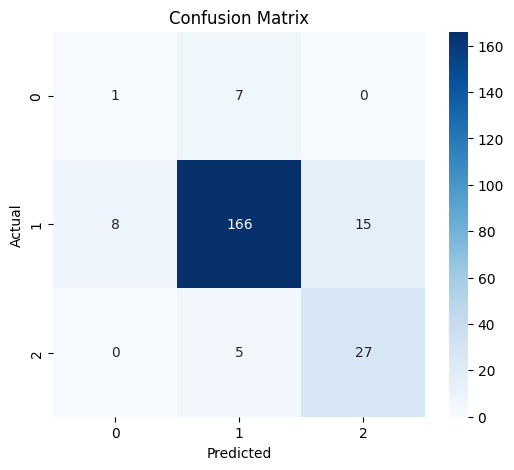



===== XGBoost =====
Score: 0.8384
              precision    recall  f1-score   support

         Low       0.10      0.12      0.11         8
      Medium       0.92      0.88      0.90       189
        High       0.64      0.78      0.70        32

    accuracy                           0.84       229
   macro avg       0.55      0.59      0.57       229
weighted avg       0.85      0.84      0.84       229

[[  1   7   0]
 [  9 166  14]
 [  0   7  25]]


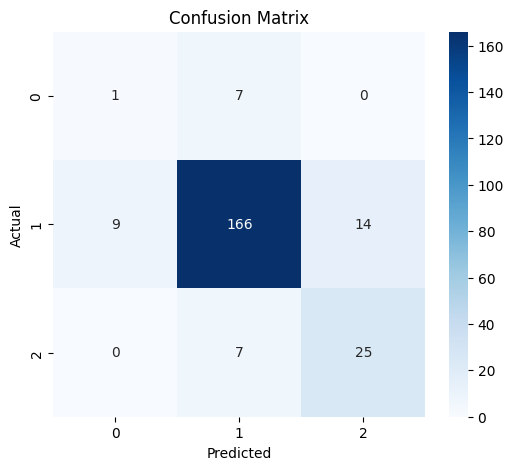



===== SVM =====
Score: 0.7598
              precision    recall  f1-score   support

         Low       0.04      0.12      0.06         8
      Medium       0.92      0.78      0.84       189
        High       0.58      0.81      0.68        32

    accuracy                           0.76       229
   macro avg       0.51      0.57      0.53       229
weighted avg       0.84      0.76      0.79       229

[[  1   7   0]
 [ 23 147  19]
 [  0   6  26]]


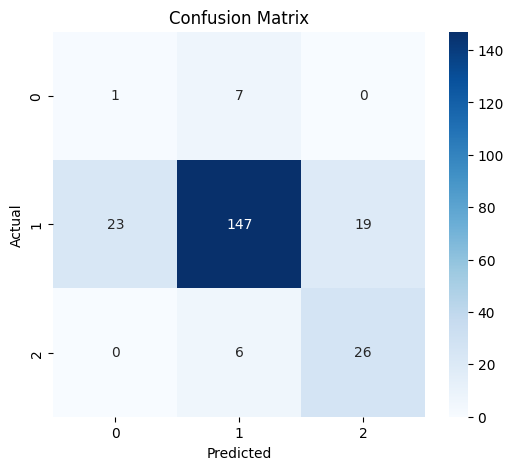



===== KNN =====
Score: 0.6943
              precision    recall  f1-score   support

         Low       0.06      0.25      0.09         8
      Medium       0.95      0.67      0.79       189
        High       0.51      0.94      0.66        32

    accuracy                           0.69       229
   macro avg       0.50      0.62      0.51       229
weighted avg       0.86      0.69      0.74       229

[[  2   5   1]
 [ 34 127  28]
 [  0   2  30]]


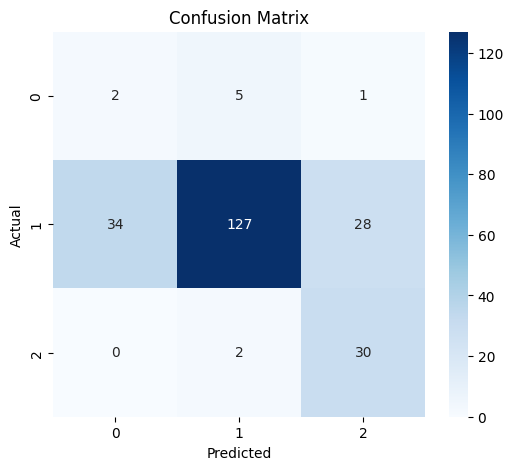

In [197]:
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
accuracy_scores = {}

# Fungsi evaluasi
def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = score
    print(f"Score: {score:.4f}")
    print(classification_report(y_test, y_pred,target_names=label_map.values()))
    print(confusion_matrix(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Loop evaluasi
for name, model in models.items():
    print(f"===== {name} =====")
    evaluate_model(model, name, X_train_scaled, y_resample, X_test_scaled, y_test)
    print("\n")

## Evaluation

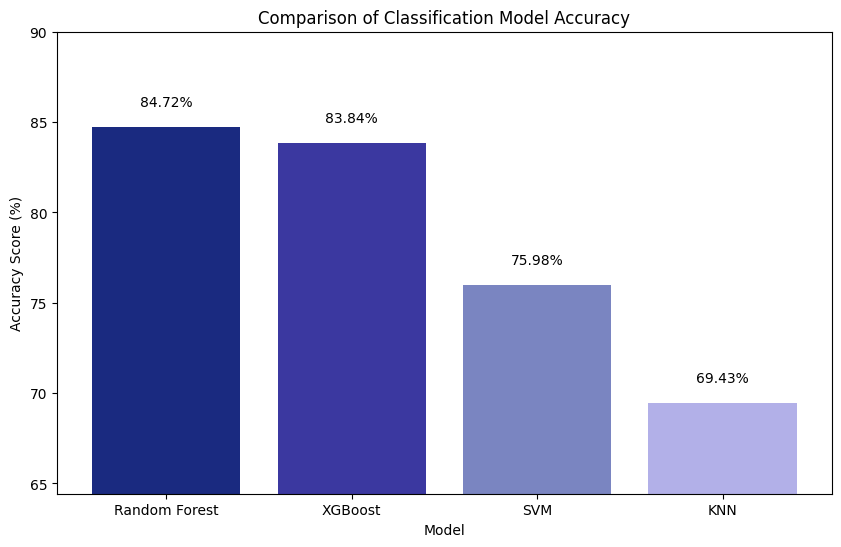

In [198]:
# Data
models_names = list(accuracy_scores.keys())
accuracy_percent = [v * 100 for v in accuracy_scores.values()]

# Custom colors: dark purple, dark blue, green, yellow
custom_colors = ['#1A2A80', '#3B38A0', '#7A85C1', '#B2B0E8']

plt.figure(figsize=(10, 6))
bars = plt.bar(models_names, accuracy_percent, color=custom_colors[:len(models_names)])

plt.title('Comparison of Classification Model Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy Score (%)')
plt.ylim(min(accuracy_percent) - 5, 90)

# Menambahkan teks persen di atas batang
for bar, score in zip(bars, accuracy_percent):
    plt.text(bar.get_x() + bar.get_width()/2, score + 1, f'{score:.2f}%', ha='center', va='bottom')

# Simpan gambar
plt.savefig('model_accuracy_comparison.png', dpi=300, bbox_inches='tight')  # simpan sebagai PNG
plt.show()

Based on the model evaluation table, the **Random Forest model** is the best performer with the highest accuracy of **0.85**. It's the most balanced model, although all models—including Random Forest and XGBoost struggle significantly with predicting class 0. This is evident from the very low precision, recall, and f1-scores for that class. The **SVM and KNN models are the weakest**, with lower overall accuracy, and they also struggle with predictions, especially for classes 0 and 1. To improve the overall performance, it's crucial to address the poor prediction of class 0, possibly due to data imbalance.

We will save the model using joblib

In [98]:
# Misal rf_model sudah dilatih
joblib.dump(models['Random Forest'], "rf_model.pkl")
print("Model berhasil disimpan ke rf_model.pkl")

Model berhasil disimpan ke rf_model.pkl


## Inference on a Single Test
To perform inference or labeling on a single piece of data, we use a trained model to make a prediction on a new, unseen data point. This process involves selecting one example from the test set, ensuring it is in the correct format, and then passing it to the model's .predict() method

In [199]:
print("--- Performing inference from the saved model ---")

# 1. Load the best model from the .pkl file
best_model = joblib.load("rf_model.pkl")

# 2. Select a single data example from the scaled test set
# We will use the first row of the test data as our example
single_test_example = X_test_scaled[100]

# 3. Reshape the data for the model
# The .predict() method expects a 2D array, so we reshape the single row
single_test_example = single_test_example.reshape(1, -1)

# 4. Make a prediction (labeling)
prediction_numeric = best_model.predict(single_test_example)

# 5. Get the actual label for comparison
actual_label_numeric = y_test.iloc[0]

# 6. Convert numeric labels to their descriptive names
prediction_label = label_map[prediction_numeric[0]]
actual_label = label_map[actual_label_numeric]

# 7. Print the results
print(f"The model predicted the label as: {prediction_label}")
print(f"The actual label for this data point is: {actual_label}")

--- Performing inference from the saved model ---
The model predicted the label as: Medium
The actual label for this data point is: Medium
